<b> In this I am going to apply decision tree model and its business interpretations of this dataset.

In [1]:
import pandas as pd
from IPython.display import display # used to display tables clearly.

df = pd.read_excel(r"C:\Users\Sai Lalit\Downloads\smartloan_business_loan_decision_tree_dataset.xlsx")
print("The Dataset loaded successfully.")

display(df.head())


The Dataset loaded successfully.


,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability,Loan_Approved
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High,Yes
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low,No
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High,Yes
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High,Yes
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium,No


In [2]:
display(df.tail())

,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability,Loan_Approved
239,SL-0240,Health Services,Manitoba,2,155901.0,-595.0,33866.0,616.0,50000,48,50309.0,No,Yes,29.0,Low,No
240,SL-0006,Construction,Ontario,4,63277.0,-1205.0,43667.0,638.0,20000,24,14991.0,No,Yes,6.0,Low,No
241,SL-0048,E-commerce,British Columbia,8,148212.0,341.0,34817.0,697.0,10000,48,4700.0,No,Yes,45.0,Medium,Yes
242,SL-0119,Restaurant,Quebec,9,320575.0,2727.0,59345.0,576.0,200000,24,161817.0,No,Yes,36.0,Low,No
243,SL-0200,E-commerce,British Columbia,4,185410.0,1838.0,47334.0,662.0,10000,60,10574.0,No,Yes,56.0,High,Yes


In [3]:
print("dataset shape:")

print(df.shape)

dataset shape:
(244, 16)


In [4]:
# finding how many columns are there in the dataset

print("column list:")

print(df.columns.tolist())

column list:
['Application_ID', 'Industry', 'Region', 'Business_Age_Years', 'Annual_Revenue', 'Monthly_Profit', 'Existing_Debt', 'Credit_Score', 'Requested_Loan_Amount', 'Loan_Term_Months', 'Collateral_Value', 'Previous_Default', 'Online_Application_Complete', 'Relationship_Length_Months', 'Cash_Flow_Stability', 'Loan_Approved']


In [5]:
print("Data Infomation")
df.info()

Data Infomation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Application_ID               244 non-null    object 
 1   Industry                     243 non-null    object 
 2   Region                       243 non-null    object 
 3   Business_Age_Years           244 non-null    int64  
 4   Annual_Revenue               243 non-null    float64
 5   Monthly_Profit               243 non-null    float64
 6   Existing_Debt                243 non-null    float64
 7   Credit_Score                 243 non-null    float64
 8   Requested_Loan_Amount        244 non-null    int64  
 9   Loan_Term_Months             244 non-null    int64  
 10  Collateral_Value             243 non-null    float64
 11  Previous_Default             243 non-null    object 
 12  Online_Application_Complete  244 non-null    object 
 13  Rela

In [6]:
# Finding how many missing values there are in the dataset

print("Missing Values in Each Column")

print("-" * 50)

# Count missing values in each column
missing_values = df.isnull().sum()

# Display the number of missing values for each column
display(missing_values)


Missing Values in Each Column
--------------------------------------------------


Application_ID                 0
Industry                       1
Region                         1
Business_Age_Years             0
Annual_Revenue                 1
Monthly_Profit                 1
Existing_Debt                  1
Credit_Score                   1
Requested_Loan_Amount          0
Loan_Term_Months               0
Collateral_Value               1
Previous_Default               1
Online_Application_Complete    0
Relationship_Length_Months     1
Cash_Flow_Stability            1
Loan_Approved                  0
dtype: int64

In [7]:
# Finding the duplicate values in the dataset

print("Number of Duplicate Rows")

print("-" * 50)

# Count the number of duplicate rows in the dataset
duplicate_rows = df.duplicated().sum()

# Display the number of duplicate rows
print(duplicate_rows)

Number of Duplicate Rows
--------------------------------------------------
4


In [8]:
# Understanding Features and target variables.

target_column = "Loan_Approved"

print("Target variable:")

print(target_column)

Target variable:
Loan_Approved


In [9]:
#Displaying the unique values in the target variables

print("Unique values:")
print(df[target_column].unique())

print("-" * 50)

#Count how many customers are in each target class

target_counts = df[target_column].value_counts()

# Display the target class counts
display(target_counts)

Unique values:
['Yes' 'No']
--------------------------------------------------


Loan_Approved
Yes    164
No      80
Name: count, dtype: int64

In [10]:
# dividing the feature into numerical and catelogical features

Numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

Catelogical_features = df.select_dtypes(include = ["object"]).columns.tolist()

Catelogical_features.remove(target_column)   

print("Numerical features:",Numerical_features)

print("-" * 50)

print("Catelogical_features:", Catelogical_features)

Numerical features: ['Business_Age_Years', 'Annual_Revenue', 'Monthly_Profit', 'Existing_Debt', 'Credit_Score', 'Requested_Loan_Amount', 'Loan_Term_Months', 'Collateral_Value', 'Relationship_Length_Months']
--------------------------------------------------
Catelogical_features: ['Application_ID', 'Industry', 'Region', 'Previous_Default', 'Online_Application_Complete', 'Cash_Flow_Stability']


In [11]:
# Data Cleaning 

df_clean = df.copy()

print("The data has been copyed successfully")

print("the Original data:",df.shape)

print("The copy data:",df_clean.shape)

The data has been copyed successfully
the Original data: (244, 16)
The copy data: (244, 16)


In [12]:
# Removing the duplicate values

duplicates_before = df_clean.duplicated().sum()

df_clean = df_clean.drop_duplicates()

print("the duplicate values in the dataset:", duplicates_before)
print("After remove the duplicate values the dataset:",df_clean)

the duplicate values in the dataset: 4
After remove the duplicate values the dataset:     Application_ID               Industry    Region  Business_Age_Years  \
0          SL-0001        Health Services   Alberta                   9   
1          SL-0002     Education Services   Ontario                   6   
2          SL-0003  Professional Services  Manitoba                   6   
3          SL-0004             E-commerce   Alberta                   0   
4          SL-0005             E-commerce  Manitoba                   9   
..             ...                    ...       ...                 ...   
235        SL-0236             Restaurant   Alberta                   2   
236        SL-0237             E-commerce   Ontario                   6   
237        SL-0238  Professional Services  Manitoba                  11   
238        SL-0239             E-commerce   Ontario                   4   
239        SL-0240        Health Services  Manitoba                   2   

     Annual_R

In [13]:
# cleaning the Missing values

Numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()

Catelogical_features = df.select_dtypes(include = ["object"]).columns.tolist()

for column in Numerical_features: 
    median_value = df_clean[column].median() #  # Calculating the median value of the each column
    df_clean[column] = df_clean[column].fillna(median_value) # Filling the median values in the columns

for column in Catelogical_features: 
    most_frequent_value = df_clean[column].mode()[0] # Finding the most frequent value in the columns
    df_clean[column] = df_clean[column].fillna(most_frequent_value) # Filling the frequent values in the columns.  

print("Missing values after cleaning:") 

print(df_clean.isnull().sum())

print("\nCleaned dataset preview:")

display(df_clean.head())

Missing values after cleaning:
Application_ID                 0
Industry                       0
Region                         0
Business_Age_Years             0
Annual_Revenue                 0
Monthly_Profit                 0
Existing_Debt                  0
Credit_Score                   0
Requested_Loan_Amount          0
Loan_Term_Months               0
Collateral_Value               0
Previous_Default               0
Online_Application_Complete    0
Relationship_Length_Months     0
Cash_Flow_Stability            0
Loan_Approved                  0
dtype: int64

Cleaned dataset preview:


,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability,Loan_Approved
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High,Yes
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low,No
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High,Yes
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High,Yes
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium,No


In [14]:
Catelogical_features = df.select_dtypes(include = ["object"]).columns.tolist()

Catelogical_features.remove(target_column)   

print("Numerical features:",Numerical_features)

print("-" * 50)

print("Catelogical_features:", Catelogical_features)

Numerical features: ['Business_Age_Years', 'Annual_Revenue', 'Monthly_Profit', 'Existing_Debt', 'Credit_Score', 'Requested_Loan_Amount', 'Loan_Term_Months', 'Collateral_Value', 'Relationship_Length_Months']
--------------------------------------------------
Catelogical_features: ['Application_ID', 'Industry', 'Region', 'Previous_Default', 'Online_Application_Complete', 'Cash_Flow_Stability']


In [15]:
# Count the number of numerical features
num_count = len(Numerical_features)
# Count the number of categorical features
cat_count = len(Catelogical_features)
# Print the number of numerical features
print("Number of numerical features:", num_count)
# Print the number of categorical features
print("Number of categorical features:", cat_count)

Number of numerical features: 9
Number of categorical features: 6


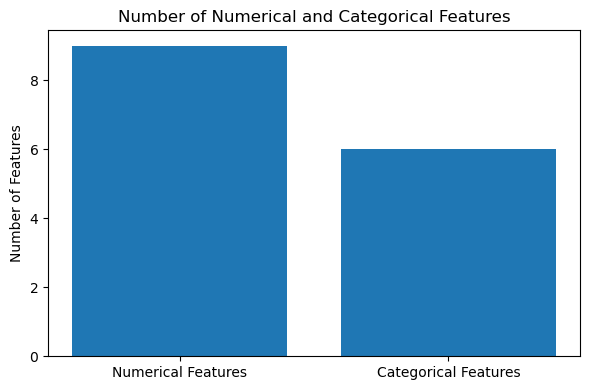

In [16]:
# Import matplotlib for creating charts
import matplotlib.pyplot as plt
# Create labels for the chart
feature_type_labels = ["Numerical Features", "Categorical Features"]
# Create values for the chart
feature_type_counts = [num_count, cat_count]
# Create a figure for the chart
plt.figure(figsize=(6, 4))
# Create a bar chart
plt.bar(feature_type_labels, feature_type_counts)
# Add a chart title
plt.title("Number of Numerical and Categorical Features")
# Add a label to the y-axis
plt.ylabel("Number of Features")
# Adjust the layout
plt.tight_layout()
# Display the chart
plt.show()

In [18]:
# creating the x and y columns from the dataset

x = df_clean.drop(columns=[target_column])
# Create y by selecting only the target column
y = df_clean[target_column]
# Print a message to confirm that X and y have been created
print("X and y have been defined successfully.")

print("Shape of X:")
# Display the number of rows and columns in X
print(x.shape)
# Print a separator line
print("-" * 50)
# Print the shape of y
print("Shape of y:")
# Display the number of rows in y
print(y.shape)

X and y have been defined successfully.
Shape of X:
(240, 15)
--------------------------------------------------
Shape of y:
(240,)


In [19]:
# Displaying the first five rows in the dataset

print("First five rows of X:")
# Print a separator line
print("-" * 50)
# Display the first five rows of X
display(x.head())

First five rows of X:
--------------------------------------------------


,Application_ID,Industry,Region,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Previous_Default,Online_Application_Complete,Relationship_Length_Months,Cash_Flow_Stability
0,SL-0001,Health Services,Alberta,9,430092.0,2058.0,11573.0,667.0,10000,48,2652.0,No,Yes,20.0,High
1,SL-0002,Education Services,Ontario,6,102057.0,-739.0,83367.0,563.0,25000,60,4761.0,No,Yes,39.0,Low
2,SL-0003,Professional Services,Manitoba,6,244945.0,1138.0,170897.0,749.0,10000,12,3585.0,No,Yes,25.0,High
3,SL-0004,E-commerce,Alberta,0,267415.0,5003.0,91078.0,622.0,20000,24,13003.0,No,Yes,20.0,High
4,SL-0005,E-commerce,Manitoba,9,139350.0,1333.0,40216.0,641.0,30000,36,14442.0,Yes,No,24.0,Medium


In [20]:
print("First five values of y:")
# Print a separator line
print("-" * 50)
# Display the first five values of y
display(y.head())

First five values of y:
--------------------------------------------------


0    Yes
1     No
2    Yes
3    Yes
4     No
Name: Loan_Approved, dtype: object

In [21]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
# Use X as the input features
x,
# Use y as the target variable
y,
# Use 20% of the data for testing
test_size=0.2,
# Keep the same target class distribution in train and test sets
stratify=y,
# Use a fixed random state to make the result reproducible
random_state=42)

# Print a message to confirm that the data has been split
print("Data has been split into training and testing sets.")

Data has been split into training and testing sets.


In [22]:
print("x_train shape:")
# Display the number of rows and columns in X_train
print(x_train.shape)
# Print a separator line
print("-" * 50)
# Print the shape of X_test
print("X_test shape:")
# Display the number of rows and columns in X_test
print(x_test.shape)
# Print a separator line
print("-" * 50)
# Print the shape of y_train
print("y_train shape:")

print(y_train.shape)
# Print a separator line
print("-" * 50)
# Print the shape of y_test
print("y_test shape:")
# Display the number of target values in y_test
print(y_test.shape)

x_train shape:
(192, 15)
--------------------------------------------------
X_test shape:
(48, 15)
--------------------------------------------------
y_train shape:
(192,)
--------------------------------------------------
y_test shape:
(48,)


In [24]:
print("Target distribution in training set:")
# Print a separator line
print("-" * 50)
# Count the number of Yes and No values in y_train
train_distribution = y_train.value_counts()
# Display the target distribution in the training set
display(train_distribution)

Target distribution in training set:
--------------------------------------------------


Loan_Approved
Yes    130
No      62
Name: count, dtype: int64

In [25]:
print("Target distribution in testing set:")
# Print a separator line
print("-" * 50)
28
# Count the number of Yes and No values in y_test
test_distribution = y_test.value_counts()
# Display the target distribution in the testing set
display(test_distribution)

Target distribution in testing set:
--------------------------------------------------


Loan_Approved
Yes    32
No     16
Name: count, dtype: int64

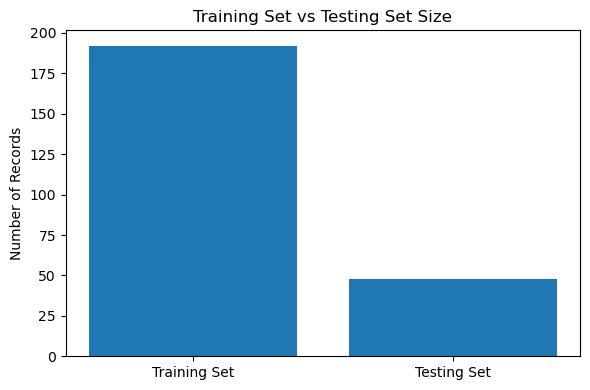

In [28]:
import matplotlib.pyplot as plt
# Create labels for the chart
split_labels = ["Training Set", "Testing Set"]
# Create values for the chart
split_sizes = [len(x_train), len(x_test)]
# Create a figure for the chart
plt.figure(figsize=(6, 4))
# Create a bar chart for train and test size
plt.bar(split_labels, split_sizes)
# Add a title to the chart
plt.title("Training Set vs Testing Set Size")
# Add a label to the y-axis
plt.ylabel("Number of Records")
# Adjust the layout
plt.tight_layout()
# Display the chart
plt.show()

In [73]:
# Preprocessing step

# Import ColumnTransformer to apply different preprocessing steps to different columns. compose import ColumnTransformer
# Import OneHotEncoder to convert categorical variables into numerical columns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Select numerical feature columns from X
numerical_features = x.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Select categorical feature columns from X
categorical_features = x.select_dtypes(include=["object"]).columns.tolist()
# Print numerical features
print("Numerical features:")
print(numerical_features)
# Print a separator line
print("-" * 50)
# Print categorical features
print("Categorical features:")
print(categorical_features)

Numerical features:
['Business_Age_Years', 'Annual_Revenue', 'Monthly_Profit', 'Existing_Debt', 'Credit_Score', 'Requested_Loan_Amount', 'Loan_Term_Months', 'Collateral_Value', 'Relationship_Length_Months']
--------------------------------------------------
Categorical features:
['Application_ID', 'Industry', 'Region', 'Previous_Default', 'Online_Application_Complete', 'Cash_Flow_Stability']


In [30]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
# Create a ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(transformers=[("categorical", encoder, categorical_features),("numerical", "passthrough", numerical_features)])
# Print a message to confirm that the preprocessor has been created
print("Preprocessor has been created successfully.")

Preprocessor has been created successfully.


In [31]:
x_train_preprocessed = preprocessor.fit_transform(x_train)
x_test_preprocessed = preprocessor.transform(x_test)

print("x_test preprocessing completed!")

print("\n")

print("Summary of preprocessing shapes:")  # Print a title for the shape summary

print("x_train before preprocessing:", x_train_preprocessed.shape)  # Print X_train shape before preprocessing

print("x_train after preprocessing:", x_train_preprocessed.shape)  # Print X_train shape after preprocessing

print("x_test before preprocessing:", x_test_preprocessed.shape)  # Print X_test shape before preprocessing

print("x_test after preprocessing:", x_test_preprocessed.shape)  # Print X_test shape after preprocessing


x_test preprocessing completed!


Summary of preprocessing shapes:
x_train before preprocessing: (192, 221)
x_train after preprocessing: (192, 221)
x_test before preprocessing: (48, 221)
x_test after preprocessing: (48, 221)


In [32]:
# Get the new feature names created from categorical variables
encoded_categorical_features = preprocessor.named_transformers_["categorical"].get_feature_names_out(categorical_features)
# Combine encoded categorical feature names with numerical feature names
processed_feature_names = list(encoded_categorical_features) + numerical_features
# Print the total number of processed features
print("Number of processed features:", len(processed_feature_names))
# Print a separator line
print("-" * 50)

# Display the processed feature names
print(processed_feature_names)

Number of processed features: 221
--------------------------------------------------
['Application_ID_SL-0001', 'Application_ID_SL-0002', 'Application_ID_SL-0003', 'Application_ID_SL-0004', 'Application_ID_SL-0007', 'Application_ID_SL-0008', 'Application_ID_SL-0010', 'Application_ID_SL-0011', 'Application_ID_SL-0012', 'Application_ID_SL-0014', 'Application_ID_SL-0015', 'Application_ID_SL-0016', 'Application_ID_SL-0018', 'Application_ID_SL-0019', 'Application_ID_SL-0020', 'Application_ID_SL-0022', 'Application_ID_SL-0023', 'Application_ID_SL-0024', 'Application_ID_SL-0025', 'Application_ID_SL-0026', 'Application_ID_SL-0027', 'Application_ID_SL-0028', 'Application_ID_SL-0029', 'Application_ID_SL-0030', 'Application_ID_SL-0031', 'Application_ID_SL-0032', 'Application_ID_SL-0033', 'Application_ID_SL-0034', 'Application_ID_SL-0035', 'Application_ID_SL-0036', 'Application_ID_SL-0037', 'Application_ID_SL-0038', 'Application_ID_SL-0040', 'Application_ID_SL-0041', 'Application_ID_SL-0042', 'App

In [33]:
# Convert processed training data into a DataFrame
x_train_processed_df = pd.DataFrame(x_train_preprocessed,columns = processed_feature_names, index = x_train.index)
# Convert processed testing data into a DataFrame
x_test_processed_df = pd.DataFrame(x_test_preprocessed,columns = processed_feature_names, index = x_test.index)
# Display the first five rows of the processed training data
display(x_train_processed_df.head())

,Application_ID_SL-0001,Application_ID_SL-0002,Application_ID_SL-0003,Application_ID_SL-0004,Application_ID_SL-0007,Application_ID_SL-0008,Application_ID_SL-0010,Application_ID_SL-0011,Application_ID_SL-0012,Application_ID_SL-0014,...,Cash_Flow_Stability_Medium,Business_Age_Years,Annual_Revenue,Monthly_Profit,Existing_Debt,Credit_Score,Requested_Loan_Amount,Loan_Term_Months,Collateral_Value,Relationship_Length_Months
135,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,181512.0,1792.0,175646.0,643.0,30000.0,48.0,16586.0,20.0
163,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,106434.0,6.0,125075.0,691.0,150000.0,60.0,86846.0,22.0
7,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,3.0,433530.0,2961.0,22761.0,608.0,150000.0,12.0,92720.0,34.0
100,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,4.0,275043.0,804.0,58754.0,578.0,200000.0,60.0,237864.0,41.0
218,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,7.0,335132.0,491.0,39115.0,675.0,100000.0,36.0,10590.0,35.0


In [34]:
# Training the decision tree

from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
# Limit the depth of the tree to make it easier to understand
max_depth=4,
# Use a fixed random state to make the result reproducible
random_state=42
)
# Print a message to confirm that the model has been created
print("Decision Tree model has been created.")

Decision Tree model has been created.


In [35]:
decision_tree_model.fit(x_train_processed_df,y_train)

print("The decision tree model has trained succesfully")

The decision tree model has trained succesfully


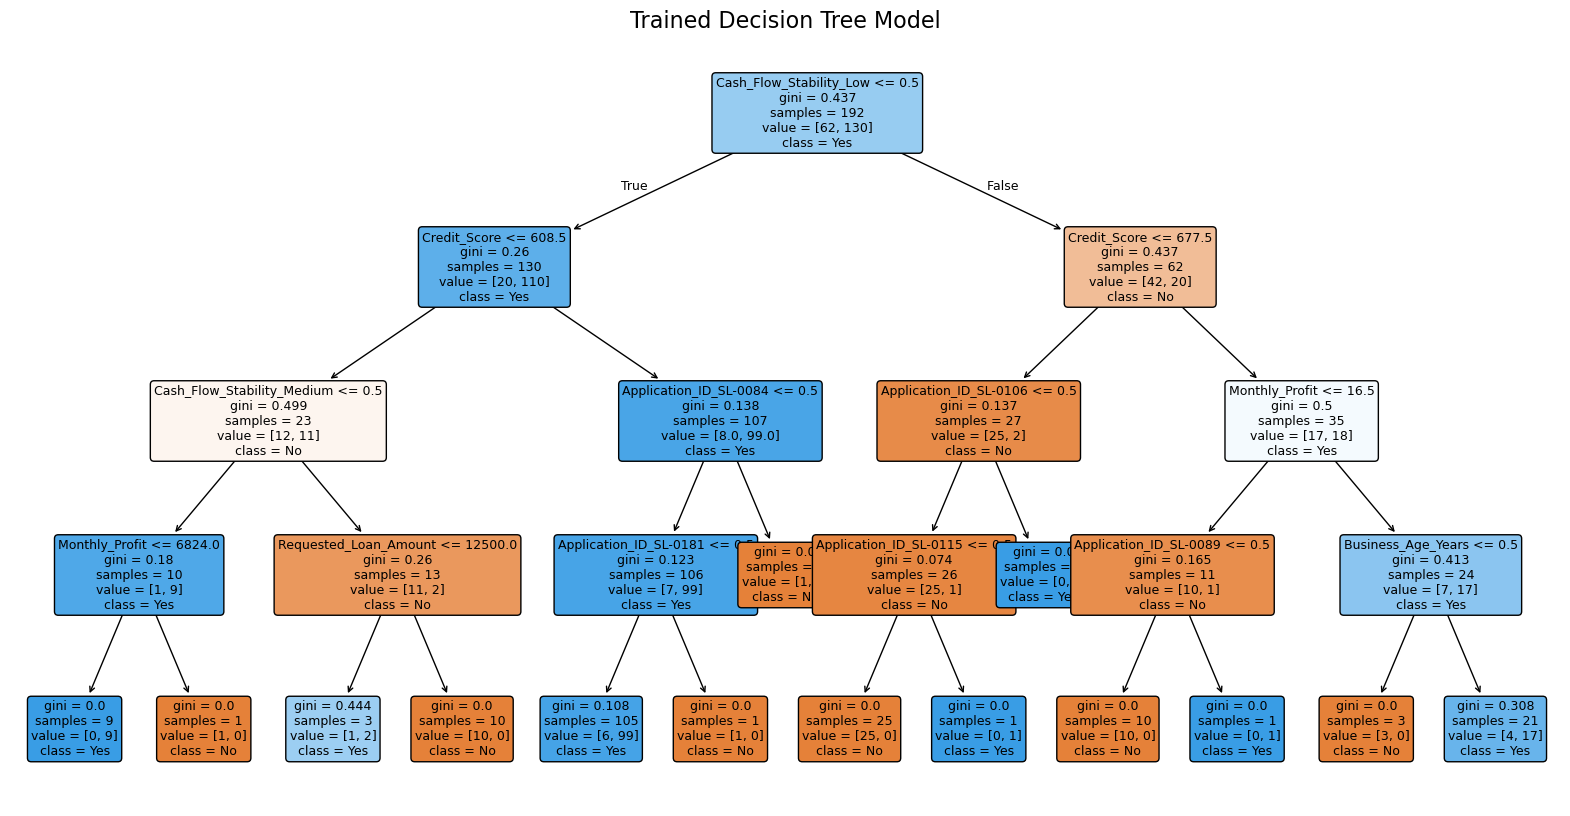

In [37]:
# Using Matplotlib, we are showing the decision tree outcome.

import matplotlib.pyplot as plt
# Import plot_tree to visualize the Decision Tree
from sklearn.tree import plot_tree
# Create a large figure for the tree visualization
plt.figure(figsize=(20, 10))
# Plot the trained Decision Tree
plot_tree(
# Use the trained Decision Tree model
decision_tree_model,
# Use feature names from the processed training data
feature_names=x_train_processed_df.columns,
# Show class names from the target variable
class_names=decision_tree_model.classes_,
# Fill the tree boxes to make the classes easier to distinguish
filled=True,
# Round the corners of the boxes
rounded=True,
# Set the font size
fontsize=9
)
# Add a title to the figure
plt.title("Trained Decision Tree Model", fontsize=16)
# Display the figure
plt.show()

In [38]:
# Get the depth of the trained Decision Tree
tree_depth = decision_tree_model.get_depth()
# Get the number of leaf nodes in the trained Decision Tree
tree_leaves = decision_tree_model.get_n_leaves()
# Print the depth of the tree
print("Decision Tree depth:", tree_depth)
# Print the number of leaf nodes
print("Number of leaf nodes:", tree_leaves)

Decision Tree depth: 4
Number of leaf nodes: 14


In [40]:
y_pred_dt = decision_tree_model.predict(x_test_processed_df)
# Print a message to confirm that predictions have been created
print("Decision Tree predictions have been created successfully.")

Decision Tree predictions have been created successfully.


In [41]:
# Create a DataFrame to compare actual and predicted values
dt_results = pd.DataFrame({
# Store the actual values from the testing set
"Actual": y_test.values,
# Store the predicted values from the Decision Tree model
"Predicted": y_pred_dt
})
# Print a title for the output
print("Actual vs Predicted Values")
# Print a separator line
print("-" * 50)
# Display the first ten actual and predicted values
display(dt_results.head(10))

Actual vs Predicted Values
--------------------------------------------------


,Actual,Predicted
0,Yes,Yes
1,No,No
2,Yes,No
3,Yes,Yes
4,No,No
5,No,Yes
6,Yes,Yes
7,Yes,Yes
8,No,No
9,Yes,Yes


In [42]:
# Now we will check the accuracy of the decision tree fro this dataset

from sklearn.metrics import accuracy_score
# Calculate the accuracy of the Decision Tree model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
# Print the Decision Tree testing accuracy
print("Decision Tree Test Accuracy:")
# Display the accuracy value
print(dt_test_accuracy)


Decision Tree Test Accuracy:
0.7916666666666666


In [43]:
# Predict the target values for the training data
y_train_pred_dt = decision_tree_model.predict(x_train_processed_df)
# Calculate the accuracy of the model on the training data
dt_train_accuracy = accuracy_score(y_train, y_train_pred_dt)
# Calculate the accuracy of the model on the testing data
dt_test_accuracy = accuracy_score(y_test, y_pred_dt)
# Print the training accuracy
print("Decision Tree Training Accuracy:", dt_train_accuracy)
# Print the testing accuracy
print("Decision Tree Testing Accuracy:", dt_test_accuracy)

Decision Tree Training Accuracy: 0.9427083333333334
Decision Tree Testing Accuracy: 0.7916666666666666


In [45]:
# Confusion matrix in decision tree for more details about the training and testing data

from sklearn.metrics import confusion_matrix
# Import ConfusionMatrixDisplay to visualize the confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
# Import matplotlib for creating the figure
import matplotlib.pyplot as plt 
# Define the class labels in a fixed order

class_labels = ["No", "Yes"]
# Calculate the confusion matrix for the Decision Tree model
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=class_labels)
# Print a title for the output
print("Decision Tree Confusion Matrix")
# Print a separator line
print("-" * 50)
# Display the confusion matrix values
print(cm_dt)

Decision Tree Confusion Matrix
--------------------------------------------------
[[11  5]
 [ 5 27]]


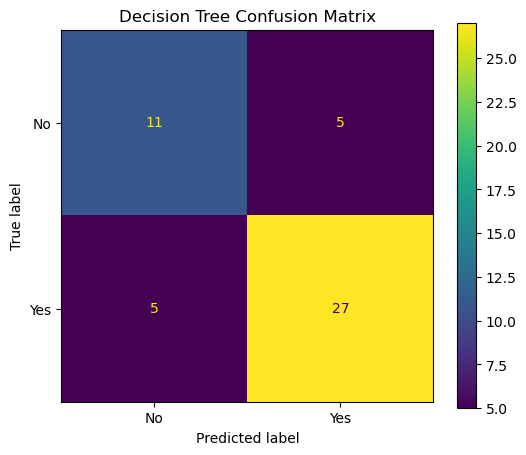

In [46]:
fig, ax = plt.subplots(figsize=(6, 5))
# Create a confusion matrix display object
disp = ConfusionMatrixDisplay(
# Use the Decision Tree confusion matrix
confusion_matrix=cm_dt,
# Use class labels for display
display_labels=class_labels)
# Plot the confusion matrix
disp.plot(ax=ax, values_format="d")
# Add a title to the figure
plt.title("Decision Tree Confusion Matrix")
# Display the figure
plt.show()

In [47]:
# Extract values from the confusion matrix
tn, fp, fn, tp = cm_dt.ravel()
# Print True Negative value
print("True Negative:", tn)
# Print False Positive value
print("False Positive:", fp)
# Print False Negative value
print("False Negative:", fn)
# Print True Positive value
print("True Positive:", tp)


True Negative: 11
False Positive: 5
False Negative: 5
True Positive: 27


In [48]:
# calculating the accuracy,precision, recoll, F1_score, Classification report

# Import accuracy_score to calculate overall correct predictions
from sklearn.metrics import accuracy_score
# Import precision_score to calculate precision
from sklearn.metrics import precision_score
# Import recall_score to calculate recall
from sklearn.metrics import recall_score
# Import f1_score to calculate the F1-score
from sklearn.metrics import f1_score
# Import classification_report to show a full performance summary
from sklearn.metrics import classification_report

In [49]:
# Calculating the accuracy score

dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:")
# Display the accuracy value
print(dt_accuracy)

Decision Tree Accuracy:
0.7916666666666666


In [51]:
# Calculating the precision score

dt_precision = precision_score(y_test, y_pred_dt, pos_label="Yes",zero_division=0)
# Print the precision score
print("Decision Tree Precision:")
# Display the precision value
print(dt_precision)

Decision Tree Precision:
0.84375


In [52]:
# Calculating the Recall score 

dt_recall = recall_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)
# Print the recall score
print("Decision Tree Recall:")
# Display the recall value
print(dt_recall)

Decision Tree Recall:
0.84375


In [53]:
# Calculating the F1 score 

dt_f1 = f1_score(y_test, y_pred_dt, pos_label="Yes", zero_division=0)
# Print the F1-score
print("Decision Tree F1-Score:")
# Display the F1-score value
print(dt_f1)

Decision Tree F1-Score:
0.84375


In [54]:
# Create a DataFrame to summarize the Decision Tree evaluation metrics
dt_metrics_table = pd.DataFrame({"Metric": ["Accuracy", "Precision", "Recall", "F1-Score"], "Score": [dt_accuracy, dt_precision, dt_recall, dt_f1]})

# Display the metrics summary table
display(dt_metrics_table)

,Metric,Score
0,Accuracy,0.791667
1,Precision,0.843750
2,Recall,0.843750
3,F1-Score,0.843750


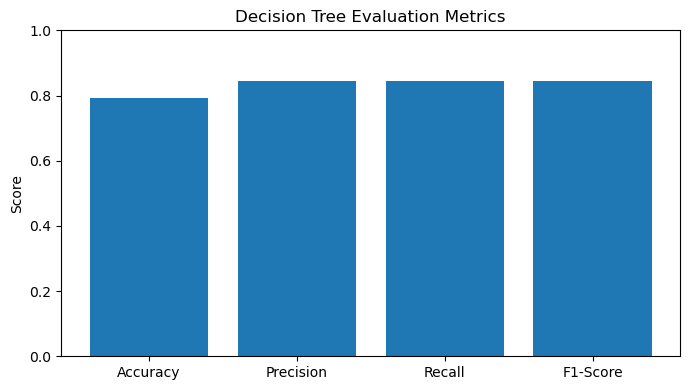

In [55]:
# ploting the above result score using matplotlib for better understanding

import matplotlib.pyplot as plt
# Create a figure for the evaluation metrics chart
plt.figure(figsize=(7, 4))
# Create a bar chart for the metrics
plt.bar(dt_metrics_table["Metric"], dt_metrics_table["Score"])
# Add a title to the chart
plt.title("Decision Tree Evaluation Metrics")
# Add a label to the y-axis
plt.ylabel("Score")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Adjust the layout so labels do not overlap
plt.tight_layout()
# Display the chart
plt.show()

In [56]:
# Print a title for the classification report
print("Decision Tree Classification Report")
# Print a separator line
print("-" * 50)
# Display the classification report for both classes
print(classification_report(y_test, y_pred_dt, zero_division=0))

Decision Tree Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.69      0.69      0.69        16
         Yes       0.84      0.84      0.84        32

    accuracy                           0.79        48
   macro avg       0.77      0.77      0.77        48
weighted avg       0.79      0.79      0.79        48



In [58]:
# In a Decision Tree, overfitting can happen when the tree becomes too deep and creates too many rules.

# Import DecisionTreeClassifier from scikit-learn
from sklearn.tree import DecisionTreeClassifier
# Create a Decision Tree model without limiting max_depth
overfit_tree_model = DecisionTreeClassifier(
# Allow the tree to grow as much as possible
max_depth=None,
# Use a fixed random state to make the result reproducible
random_state=42
)
# Train the overfitted Decision Tree model using the processed training data
overfit_tree_model.fit(x_train_processed_df, y_train)
# Print a message to confirm that the model has been trained
print("Overfitted Decision Tree model has been trained.")

Overfitted Decision Tree model has been trained.


In [60]:
# Predict the target values for the training data using the overfitted tree
y_train_pred_overfit = overfit_tree_model.predict(x_train_processed_df)
# Predict the target values for the testing data using the overfitted tree
y_test_pred_overfit = overfit_tree_model.predict(x_test_processed_df)
# Calculate training accuracy for the overfitted tree
overfit_train_accuracy = accuracy_score(y_train, y_train_pred_overfit)

# Calculate testing accuracy for the overfitted tree
overfit_test_accuracy = accuracy_score(y_test, y_test_pred_overfit)
# Print the training accuracy
print("Overfitted Tree Training Accuracy:", overfit_train_accuracy)
# Print the testing accuracy
print("Overfitted Tree Testing Accuracy:", overfit_test_accuracy)

Overfitted Tree Training Accuracy: 1.0
Overfitted Tree Testing Accuracy: 0.7916666666666666


In [62]:
# Predict the target values for the training data using the controlled Decision Tree
y_train_pred_controlled = decision_tree_model.predict(x_train_processed_df)
# Predict the target values for the testing data using the controlled Decision Tree
y_test_pred_controlled = decision_tree_model.predict(x_test_processed_df)
# Calculate training accuracy for the controlled Decision Tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)
# Calculate testing accuracy for the controlled Decision Tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)
# Create a comparison table for both models
overfitting_comparison = pd.DataFrame({
# Store the model names
"Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
# Store the training accuracy values
"Training Accuracy": [controlled_train_accuracy, overfit_train_accuracy],
# Store the testing accuracy values
"Testing Accuracy": [controlled_test_accuracy, overfit_test_accuracy]})
# Display the comparison table
display(overfitting_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Controlled Decision Tree,0.942708,0.791667
1,Overfitted Decision Tree,1.000000,0.791667


<Figure size 800x500 with 0 Axes>

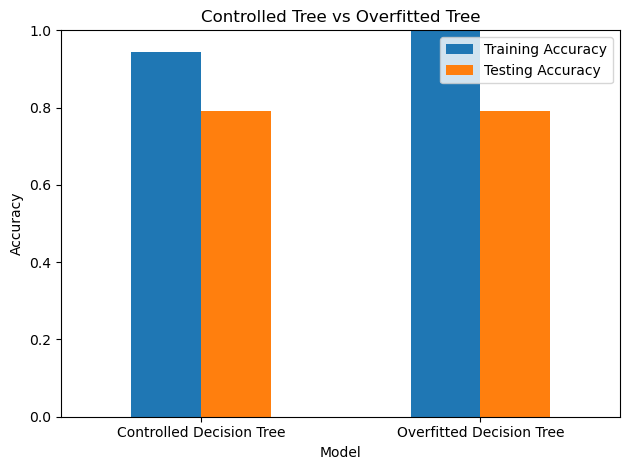

In [63]:
import matplotlib.pyplot as plt
# Set the model column as the index for better plotting
overfitting_comparison_plot = overfitting_comparison.set_index("Model")
# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))
# Create a bar chart for training and testing accuracy
overfitting_comparison_plot.plot(kind="bar")
# Add a title to the chart
plt.title("Controlled Tree vs Overfitted Tree")
# Add a label to the y-axis
plt.ylabel("Accuracy")
# Set the y-axis range from 0 to 1
plt.ylim(0, 1)
# Rotate x-axis labels for better readability
plt.xticks(rotation=0)
# Adjust layout to avoid overlap
plt.tight_layout()
# Display the chart
plt.show()

In [65]:
# Get the depth of the controlled Decision Tree
controlled_tree_depth = decision_tree_model.get_depth()
# Get the number of leaf nodes in the controlled Decision Tree
controlled_tree_leaves = decision_tree_model.get_n_leaves()
# Get the depth of the overfitted Decision Tree
overfit_tree_depth = overfit_tree_model.get_depth()
# Get the number of leaf nodes in the overfitted Decision Tree
overfit_tree_leaves = overfit_tree_model.get_n_leaves()
# Create a table to compare tree complexity
tree_complexity_table = pd.DataFrame({"Model": ["Controlled Decision Tree", "Overfitted Decision Tree"],
                                      "Tree Depth": [controlled_tree_depth, overfit_tree_depth],
                                        "Number of Leaves": [controlled_tree_leaves, overfit_tree_leaves]})
# Display the tree complexity table
display(tree_complexity_table)

,Model,Tree Depth,Number of Leaves
0,Controlled Decision Tree,4,14
1,Overfitted Decision Tree,10,24


In [67]:
# To find out the controlled decision tree, we need 
# A very deep tree may memorize the training data instead of learning general patterns.
# To reduce overfitting, we can control the complexity of the Decision Tree using parameters such as:
# max_depth, min_samples_split, min_samples_leaf

controlled_tree_model = DecisionTreeClassifier(
# Limit the maximum depth of the tree
max_depth=4,
# Require at least 5 samples in each leaf node
min_samples_leaf=5,
# Use a fixed random state for reproducible results
random_state=42
)
# Train the controlled Decision Tree model
controlled_tree_model.fit(x_train_processed_df, y_train)
# Print a message to confirm that the controlled model has been trained
print("Controlled Decision Tree model has been trained successfully.")

Controlled Decision Tree model has been trained successfully.


In [72]:

# Predict the target values for the training data
y_train_pred_controlled = controlled_tree_model.predict(x_train_processed_df)

# Predict the target values for the testing data
y_test_pred_controlled = controlled_tree_model.predict(x_test_processed_df)

# Calculate training accuracy for the controlled tree
controlled_train_accuracy = accuracy_score(y_train, y_train_pred_controlled)

# Calculate testing accuracy for the controlled tree
controlled_test_accuracy = accuracy_score(y_test, y_test_pred_controlled)

# Print the training accuracy
print("Controlled Decision Tree Training Accuracy:", controlled_train_accuracy)

# Print the testing accuracy
print("Controlled Decision Tree Testing Accuracy:", controlled_test_accuracy)

Controlled Decision Tree Training Accuracy: 0.9166666666666666
Controlled Decision Tree Testing Accuracy: 0.7916666666666666


In [74]:
# Calculate training accuracy for the original Decision Tree model
original_train_accuracy = accuracy_score(y_train, decision_tree_model.predict(x_train_processed_df))
# Calculate testing accuracy for the original Decision Tree model
original_test_accuracy = accuracy_score(y_test, decision_tree_model.predict(x_test_processed_df))
# Create a comparison table
tree_control_comparison = pd.DataFrame({
# Store model names
"Model": ["Original Decision Tree", "Controlled Decision Tree"],
# Store training accuracy values
"Training Accuracy": [original_train_accuracy, controlled_train_accuracy],
# Store testing accuracy values
"Testing Accuracy": [original_test_accuracy, controlled_test_accuracy]})
# Display the comparison table
display(tree_control_comparison)

,Model,Training Accuracy,Testing Accuracy
0,Original Decision Tree,0.942708,0.791667
1,Controlled Decision Tree,0.916667,0.791667


<Figure size 800x500 with 0 Axes>

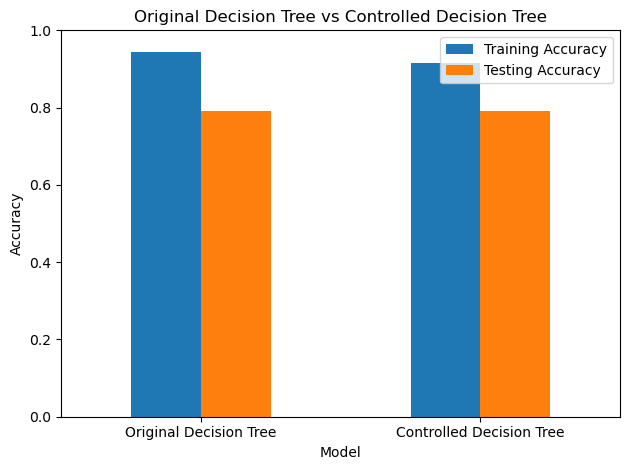

In [71]:
# Set the model column as the index for plotting
tree_control_plot = tree_control_comparison.set_index("Model")

# Create a figure for the comparison chart
plt.figure(figsize=(8, 5))

# Create a bar chart for training and testing accuracy
tree_control_plot.plot(kind="bar")

# Add a title to the chart
plt.title("Original Decision Tree vs Controlled Decision Tree")

# Add a label to the y-axis
plt.ylabel("Accuracy")

# Set the y-axis range from 0 to 1
plt.ylim(0, 1)

# Rotate x-axis labels to keep them readable
plt.xticks(rotation=0)

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

In [75]:
# Get the depth of the original Decision Tree
original_depth = decision_tree_model.get_depth()
# Get the number of leaves in the original Decision Tree
original_leaves = decision_tree_model.get_n_leaves()
# Get the depth of the controlled Decision Tree
controlled_depth = controlled_tree_model.get_depth()
# Get the number of leaves in the controlled Decision Tree
controlled_leaves = controlled_tree_model.get_n_leaves()
# Create a table to compare tree complexity
complexity_comparison = pd.DataFrame({
# Store model names
"Model": ["Original Decision Tree", "Controlled Decision Tree"],
# Store tree depth values
"Tree Depth": [original_depth, controlled_depth],

# Store number of leaves
"Number of Leaves": [original_leaves, controlled_leaves]})

# Display the complexity comparison table
display(complexity_comparison)

,Model,Tree Depth,Number of Leaves
0,Original Decision Tree,4,14
1,Controlled Decision Tree,4,15
